Imports and Data Fetching

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import warnings
from scipy.optimize import minimize
warnings.filterwarnings('ignore')

# Define 10 diverse assets for the portfolio
tickers = ['TSLA', 'WMT', 'BAC', 'GS', 'LLY', 'MRK', 'GOOG', 'META', 'AAPL', 'XOM']

# Download daily data covering the entire project span (In-Sample + Out-of-Sample)
# Period: Jan 1, 2024 to Dec 31, 2025
print("Downloading market data...")
data = yf.download(tickers, start="2024-01-01", end="2025-12-31", auto_adjust=True)

# Handle the yfinance MultiIndex to extract 'Close' prices
if isinstance(data.columns, pd.MultiIndex):
    prices = data['Close']
else:
    prices = data

# Calculate daily arithmetic returns and drop NAs
returns = prices.pct_change().dropna()

# Split data into Training (In-Sample) and Testing (Out-of-Sample)
returns_is = returns.loc['2024-01-01':'2025-09-30']
returns_oos = returns.loc['2025-10-01':'2025-12-31']

print(f"In-Sample (Training) data points: {len(returns_is)}")
print(f"Out-of-Sample (Testing) data points: {len(returns_oos)}")
display(returns_is.head())

[**********************50%                       ]  5 of 10 completed

[*********************100%***********************]  10 of 10 completed

In-Sample (Training) data points: 437
Out-of-Sample (Testing) data points: 63


Ticker,AAPL,BAC,GOOG,GS,LLY,META,MRK,TSLA,WMT,XOM
Date,,,,,,,,,,
2024-01-03,-0.007488,-0.010915,0.005732,-0.016765,0.043060,-0.005256,0.013511,-0.040134,0.000063,0.008402
2024-01-04,-0.012700,0.008053,-0.016529,0.003038,-0.005180,0.007693,0.019517,-0.002181,-0.009667,-0.008719
2024-01-05,-0.004013,0.018639,-0.004709,0.009113,0.006591,0.013915,0.001795,-0.001849,-0.006656,0.003030
2024-01-08,0.024175,-0.007842,0.022855,0.006262,0.012093,0.019065,0.001365,0.012464,0.009827,-0.016662
2024-01-09,-0.002263,-0.015515,0.014446,-0.013167,-0.000879,-0.003430,0.008945,-0.022832,0.006698,-0.012386


Ticker,AAPL,BAC,GOOG,GS,LLY,META,MRK,TSLA,WMT,XOM
Ticker,,,,,,,,,,
AAPL,0.000337,0.000108,0.000158,0.000143,0.000065,0.000172,0.000053,0.000345,0.000085,0.000061
BAC,0.000108,0.000256,0.000088,0.000228,0.000059,0.000125,0.000028,0.000235,0.000065,0.000081
GOOG,0.000158,0.000088,0.000357,0.000131,0.000046,0.000201,0.000012,0.000309,0.000047,0.000022
GS,0.000143,0.000228,0.000131,0.000336,0.000091,0.000176,0.000029,0.000339,0.000077,0.000090
LLY,0.000065,0.000059,0.000046,0.000091,0.000523,0.000147,0.000117,0.000117,0.000061,0.000022
META,0.000172,0.000125,0.000201,0.000176,0.000147,0.000566,0.000024,0.000326,0.000089,0.000037
MRK,0.000053,0.000028,0.000012,0.000029,0.000117,0.000024,0.000254,0.000035,0.000023,0.000029
TSLA,0.000345,0.000235,0.000309,0.000339,0.000117,0.000326,0.000035,0.001707,0.000143,0.000065
WMT,0.000085,0.000065,0.000047,0.000077,0.000061,0.000089,0.000023,0.000143,0.000183,0.000012


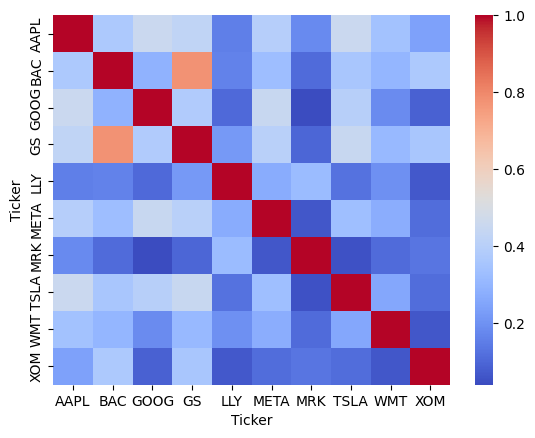

In [ ]:
import seaborn as sns

corr = returns_is.corr()
sns.heatmap(corr, cmap="coolwarm")

cov = returns_is.cov()
display(cov)


Step 1 - Optimal Kelly & Constrained Kelly Optimization

In [ ]:
returns_is = returns_is[tickers]

def kelly_objective(weights, returns_matrix):
    port_returns = np.dot(returns_matrix.values, weights)
    log_returns = np.log(1 + port_returns + 1e-9)
    return -np.mean(log_returns)

num_assets = len(tickers)
init_weights = np.ones(num_assets) / num_assets

# Base constraint: weights must sum to 1 (fully invested portfolio)
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

# Unconstrained Kelly bounds
bounds_standard = tuple((0, 1) for _ in range(num_assets))
res_kelly_std = minimize(
    kelly_objective, init_weights, args=(returns_is,),
    method='SLSQP', bounds=bounds_standard, constraints=constraints,
    options={'disp': False, 'maxiter': 1000}
)

# Constrained Kelly bounds (Max 20% per asset)
bounds_constrained = tuple((0, 0.20) for _ in range(num_assets))
res_kelly_constrained = minimize(
    kelly_objective, init_weights, args=(returns_is,),
    method='SLSQP', bounds=bounds_constrained, constraints=constraints,
    options={'disp': False, 'maxiter': 1000}
)

results_df = pd.DataFrame({
    'Asset': tickers,
    'Standard Kelly': np.round(res_kelly_std.x, 4),
    'Constrained Kelly (Max 20%)': np.round(res_kelly_constrained.x, 4)
})

print("Optimal Portfolio Weights (In-Sample):")
display(results_df)

Optimal Portfolio Weights (In-Sample):


,Asset,Standard Kelly,Constrained Kelly (Max 20%)
0,TSLA,0.2134,0.2000
1,WMT,0.1738,0.1956
2,BAC,0.0631,0.0704
3,GS,0.2064,0.2000
4,LLY,0.0000,0.0000
5,MRK,0.0000,0.0000
6,GOOG,0.1198,0.1340
7,META,0.2235,0.2000
8,AAPL,0.0000,0.0000
9,XOM,0.0000,0.0000


Step 2 - Out-of-Sample Performance Comparison

In [ ]:
# Align Out-of-Sample columns just in case
returns_oos = returns_oos[tickers]

# 1. Base Portfolio: Constrained Kelly Weights
kelly_weights = res_kelly_constrained.x

# 2. Half-Kelly: 50% invested in the Kelly portfolio, 50% in cash (0% return assumed for simplicity)
half_kelly_weights = kelly_weights * 0.5

# 3. Double-Kelly: 200% invested (leveraged 2x). Borrowing 100% cash.
double_kelly_weights = kelly_weights * 2.0

# Calculate daily portfolio returns for Out-of-Sample (OOS) period
kelly_ret_oos = np.dot(returns_oos.values, kelly_weights)
half_kelly_ret_oos = np.dot(returns_oos.values, half_kelly_weights)
double_kelly_ret_oos = np.dot(returns_oos.values, double_kelly_weights)

df_oos = pd.DataFrame({
    'Kelly': kelly_ret_oos,
    'Half-Kelly': half_kelly_ret_oos,
    'Double-Kelly': double_kelly_ret_oos
}, index=returns_oos.index)

# Mathematical definitions for Risk/Performance metrics
def calc_cumulative_return(ret):
    return np.prod(1 + ret) - 1

def calc_sharpe_ratio(ret, risk_free_rate=0.0):
    excess_ret = ret - risk_free_rate
    # Annualized Sharpe (sqrt of 252 trading days)
    return (np.mean(excess_ret) / np.std(excess_ret)) * np.sqrt(252)

def calc_max_drawdown(ret):
    cum_returns = np.cumprod(1 + ret)
    peak = np.maximum.accumulate(cum_returns)
    drawdown = (cum_returns - peak) / peak
    return np.min(drawdown)

def calc_cvar(ret, alpha=0.05):
    # 95% Conditional Value at Risk (Expected Shortfall)
    var_95 = np.percentile(ret, alpha * 100)
    cvar_95 = ret[ret <= var_95].mean()
    return cvar_95

# Compute metrics and format the table
metrics = []
for col in df_oos.columns:
    r = df_oos[col]
    metrics.append({
        'Portfolio Strategy': col,
        'Cumulative Return': f"{calc_cumulative_return(r):.2%}",
        'Sharpe Ratio': f"{calc_sharpe_ratio(r):.2f}",
        'Max Drawdown': f"{calc_max_drawdown(r):.2%}",
        '95%-cVaR': f"{calc_cvar(r):.2%}"
    })

df_metrics = pd.DataFrame(metrics).set_index('Portfolio Strategy')
print("Step 2: Out-of-Sample Performance Comparison (Oct 1 - Dec 31, 2025)")
display(df_metrics)

Step 2: Out-of-Sample Performance Comparison (Oct 1 - Dec 31, 2025)


,Cumulative Return,Sharpe Ratio,Max Drawdown,95%-cVaR
Portfolio Strategy,,,,
Kelly,7.46%,1.65,-6.86%,-2.45%
Half-Kelly,3.77%,1.65,-3.46%,-1.23%
Double-Kelly,14.48%,1.65,-13.48%,-4.90%


Step 2 Plot (Cumulative Returns Over Time)

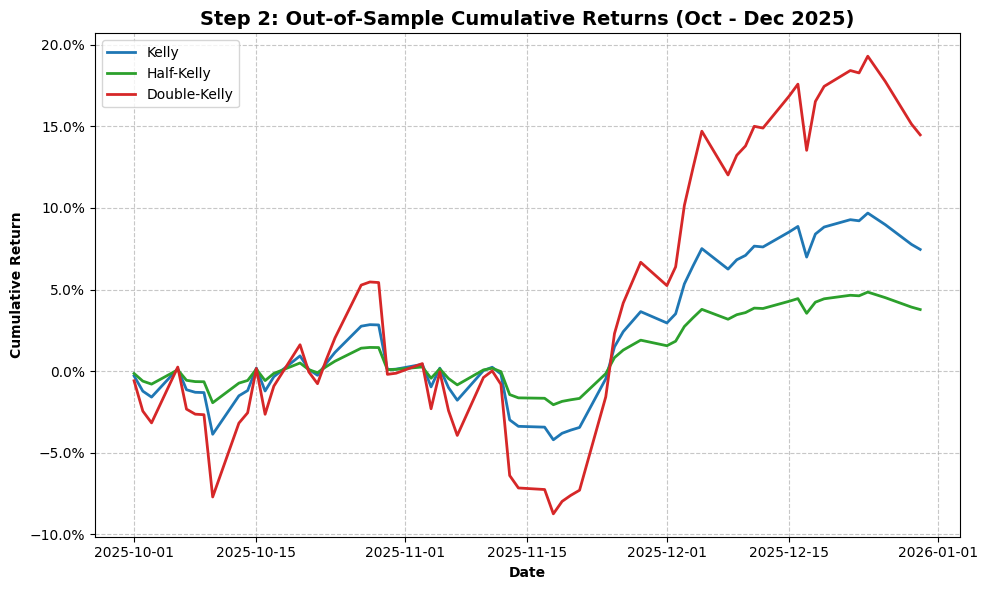

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Calculate cumulative returns over time for the OOS period
cum_returns_oos = (1 + df_oos).cumprod() - 1

# Create the plot
plt.figure(figsize=(10, 6))

# Define colors for clarity
colors = {'Kelly': '#1f77b4', 'Half-Kelly': '#2ca02c', 'Double-Kelly': '#d62728'}

for col in cum_returns_oos.columns:
    plt.plot(cum_returns_oos.index, cum_returns_oos[col] * 100, label=col, color=colors[col], linewidth=2)

plt.title('Step 2: Out-of-Sample Cumulative Returns (Oct - Dec 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Cumulative Return', fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

# Format y-axis as percentage
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()

# Save the plot
plt.savefig('step2_cumulative_returns.png', dpi=300, bbox_inches='tight')
plt.show()

Step 3 - K-Fold Cross Validation Backtesting

In [ ]:
from sklearn.model_selection import KFold

# Use the full 2-year dataset
returns_full = returns[tickers]

# Define K-Fold parameters (5 splits = 20% test data per fold)
kf = KFold(n_splits=5, shuffle=False)

fold_weight = []
fold_metrics = []
fold_number = 1

print("Starting K-Fold Cross Validation (5 Folds)...")

for train_index, test_index in kf.split(returns_full):
    # Split data
    train_data = returns_full.iloc[train_index]
    test_data = returns_full.iloc[test_index]

    # 1. Train the model (Find Constrained Kelly Weights)
    res_cv = minimize(
        kelly_objective, init_weights, args=(train_data,),
        method='SLSQP', bounds=bounds_constrained, constraints=constraints,
        options={'disp': False, 'maxiter': 1000}
    )

    weights_cv = res_cv.x

    # 2. Test the model (Apply weights to test data)
    port_ret_cv = np.dot(test_data.values, weights_cv)

    # 3. Calculate Performance Metrics for this fold
    fold_metrics.append({
        'Fold': fold_number,
        'Cum Return': calc_cumulative_return(port_ret_cv),
        'Sharpe Ratio': calc_sharpe_ratio(port_ret_cv),
        'Max Drawdown': calc_max_drawdown(port_ret_cv),
        '95%-cVaR': calc_cvar(port_ret_cv),
    })

    fold_weight.append({
        'Fold': fold_number,
        'Kelly Weight': [f"{x:.2f}" for x in weights_cv]
    })

    fold_number += 1

# Format and display the results
df_kfold = pd.DataFrame(fold_metrics).set_index('Fold')
df_kfold_weight = pd.DataFrame(fold_weight).set_index('Fold')

# Calculate the average across all folds to get the cross-validated expected performance
df_kfold.loc['Average'] = df_kfold.mean()

# Format as percentages/decimals for readability
format_dict = {'Cum Return': '{:.2%}', 'Sharpe Ratio': '{:.2f}',
               'Max Drawdown': '{:.2%}', '95%-cVaR': '{:.2%}'}
df_kfold_styled = df_kfold.style.format(format_dict)


display(df_kfold_styled)
display(df_kfold_weight)

Starting K-Fold Cross Validation (5 Folds)...


,Cum Return,Sharpe Ratio,Max Drawdown,95%-cVaR
Fold,,,,
1,12.42%,1.95,-5.31%,-1.80%
2,14.13%,1.85,-12.60%,-3.22%
3,3.15%,0.46,-17.22%,-3.24%
4,14.36%,1.24,-16.08%,-4.36%
5,20.08%,3.10,-5.65%,-1.98%
Average,12.83%,1.72,-11.37%,-2.92%


,Kelly Weight
Fold,
1,"[0.20, 0.15, 0.07, 0.20, 0.07, 0.00, 0.16, 0.0..."
2,"[0.14, 0.13, 0.09, 0.19, 0.13, 0.00, 0.20, 0.1..."
3,"[0.10, 0.15, 0.05, 0.20, 0.19, 0.00, 0.20, 0.1..."
4,"[0.12, 0.15, 0.07, 0.15, 0.20, 0.00, 0.19, 0.0..."
5,"[0.13, 0.20, 0.09, 0.20, 0.03, 0.00, 0.10, 0.2..."


Step 3 Plot (K-Fold Cross Validation Results)

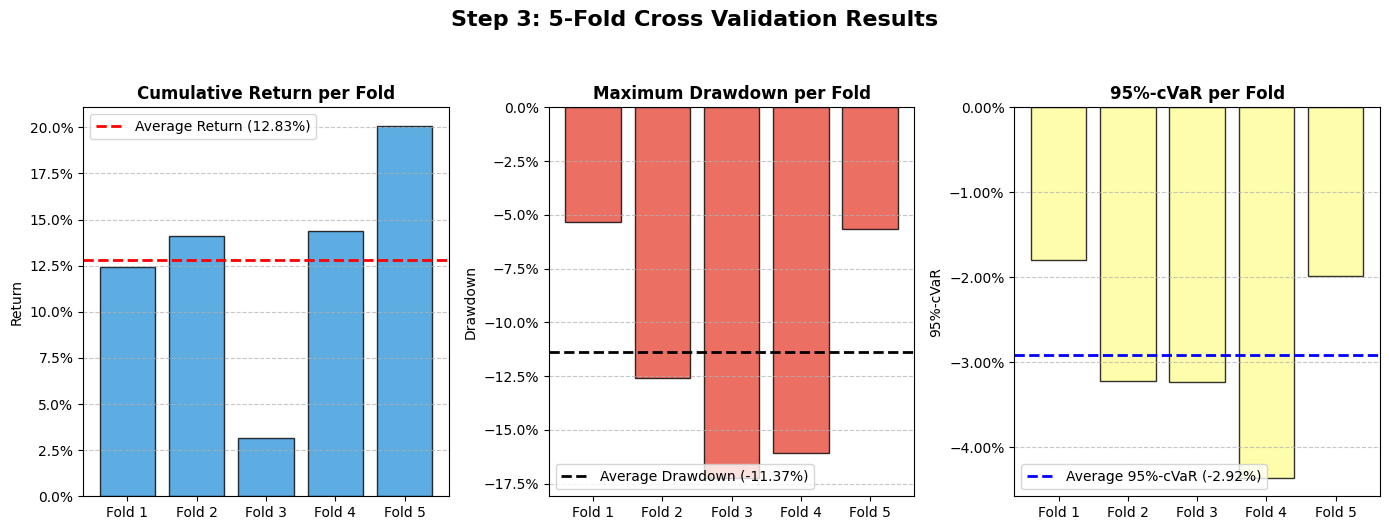

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Create a 1x2 figure (Side-by-side bar charts)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

# Extract the folds (excluding the 'Average' row) for the x-axis
folds = [f"Fold {i}" for i in df_kfold.index[:-1]]
returns_cv = df_kfold['Cum Return'].iloc[:-1] * 100
drawdowns_cv = df_kfold['Max Drawdown'].iloc[:-1] * 100
cvar_cv = df_kfold['95%-cVaR'].iloc[:-1] * 100

# Plot 1: Cumulative Returns per fold
ax1.bar(folds, returns_cv, color='#3498db', edgecolor='black', alpha=0.8)
avg_ret = df_kfold['Cum Return'].loc['Average'] * 100
ax1.axhline(avg_ret, color='red', linestyle='--', linewidth=2, label=f"Average Return ({avg_ret:.2f}%)")
ax1.set_title('Cumulative Return per Fold', fontweight='bold')
ax1.set_ylabel('Return')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Max Drawdown per fold
ax2.bar(folds, drawdowns_cv, color='#e74c3c', edgecolor='black', alpha=0.8)
avg_dd = df_kfold['Max Drawdown'].loc['Average'] * 100
ax2.axhline(avg_dd, color='black', linestyle='--', linewidth=2, label=f"Average Drawdown ({avg_dd:.2f}%)")
ax2.set_title('Maximum Drawdown per Fold', fontweight='bold')
ax2.set_ylabel('Drawdown')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Plot 3: 95%-cVaR per fold
ax3.bar(folds, cvar_cv, color='#fdfd96', edgecolor='black', alpha=0.8)
avg_cvar = df_kfold['95%-cVaR'].loc['Average'] * 100
ax3.axhline(avg_cvar, color='blue', linestyle='--', linewidth=2, label=f"Average 95%-cVaR ({avg_cvar:.2f}%)")
ax3.set_title('95%-cVaR per Fold', fontweight='bold')
ax3.set_ylabel('95%-cVaR')
ax3.yaxis.set_major_formatter(mtick.PercentFormatter())
ax3.legend()
ax3.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Step 3: 5-Fold Cross Validation Results', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()

# Save the plot
plt.savefig('step3_kfold_results.png', dpi=300, bbox_inches='tight')
plt.show()

Step 4 & 5 - Denoising, Detoning, and Clustering (HRP)

In [ ]:
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist, squareform

# ---------------------------------------------------------
# 1. DENOISING THE CORRELATION MATRIX (Marcenko-Pastur)
# ---------------------------------------------------------
def get_pca(matrix):
    eVal, eVec = np.linalg.eigh(matrix)
    indices = eVal.argsort()[::-1] # Sort descending
    eVal, eVec = eVal[indices], eVec[:, indices]
    eVal = np.diagflat(eVal)
    return eVal, eVec

def denoised_corr(returns_df):
    T, N = returns_df.shape
    corr = returns_df.corr().values

    eVal, eVec = get_pca(corr)

    q = T / N
    eMax = (1 + (1 / np.sqrt(q)))**2

    diag_eVal = np.diag(eVal).copy()
    noise_indices = diag_eVal < eMax

    if noise_indices.sum() > 0:
        avg_noise = diag_eVal[noise_indices].mean()
        diag_eVal[noise_indices] = avg_noise

    denoised_eVal = np.diagflat(diag_eVal)
    corr_denoised = np.dot(eVec, denoised_eVal).dot(eVec.T)

    diag_elements = np.diag(corr_denoised)
    scaling_matrix = np.diag(1 / np.sqrt(diag_elements))
    corr_denoised = np.dot(scaling_matrix, corr_denoised).dot(scaling_matrix)

    # ENFORCE SYMMETRY TO FIX FLOATING POINT ERRORS
    corr_denoised = (corr_denoised + corr_denoised.T) / 2.0
    np.fill_diagonal(corr_denoised, 1.0)

    return pd.DataFrame(corr_denoised, index=returns_df.columns, columns=returns_df.columns)

def corr2cov(corr, std):
    return corr * np.outer(std, std)

corr_denoised = denoised_corr(returns_is)
std = returns_is.std().values

cov_denoised = corr2cov(corr_denoised.values,std)

cov_denoised = pd.DataFrame(
    cov_denoised,
    index=returns_is.columns,
    columns=returns_is.columns
)

# ---------------------------------------------------------
# 2. DETONING THE CORRELATION MATRIX
# ---------------------------------------------------------
def detoned_corr(denoised_corr_df):
    corr = denoised_corr_df.values
    eVal, eVec = get_pca(corr)

    market_eVal = eVal[0, 0]
    market_eVec = eVec[:, 0].reshape(-1, 1)

    corr_detoned = corr - np.dot(market_eVec, market_eVec.T) * market_eVal

    diag_elements = np.diag(corr_detoned)
    scaling_matrix = np.diag(1 / np.sqrt(np.abs(diag_elements)))
    corr_detoned = np.dot(scaling_matrix, corr_detoned).dot(scaling_matrix)

    # ENFORCE SYMMETRY TO FIX FLOATING POINT ERRORS
    corr_detoned = (corr_detoned + corr_detoned.T) / 2.0
    np.fill_diagonal(corr_detoned, 1.0)

    return pd.DataFrame(corr_detoned, index=denoised_corr_df.columns, columns=denoised_corr_df.columns)

corr_detoned = detoned_corr(corr_denoised)


# ---------------------------------------------------------
# 3. CLUSTERING: HIERARCHICAL RISK PARITY (HRP)
# ---------------------------------------------------------
def get_quasi_diag(link):
    link = link.astype(int)
    sort_ix = pd.Series([link[-1, 0], link[-1, 1]])
    num_items = link[-1, 3]
    while sort_ix.max() >= num_items:
        sort_ix.index = range(0, sort_ix.shape[0] * 2, 2)
        df0 = sort_ix[sort_ix >= num_items]
        i = df0.index
        j = df0.values - num_items
        sort_ix[i] = link[j, 0]
        df0 = pd.Series(link[j, 1], index=i + 1)
        sort_ix = pd.concat([sort_ix, df0])
        sort_ix = sort_ix.sort_index()
        sort_ix.index = range(sort_ix.shape[0])
    return sort_ix.tolist()

def get_rec_bipart(cov, sort_ix):
    w = pd.Series(1.0, index=sort_ix)
    c_items = [sort_ix]
    while len(c_items) > 0:
        c_items = [i[j:k] for i in c_items for j, k in ((0, len(i) // 2), (len(i) // 2, len(i))) if len(i) > 1]
        for i in range(0, len(c_items), 2):
            c_items0 = c_items[i]
            c_items1 = c_items[i + 1]

            c_var0 = get_cluster_var(cov, c_items0)
            c_var1 = get_cluster_var(cov, c_items1)

            alpha = 1 - c_var0 / (c_var0 + c_var1)
            w[c_items0] *= alpha
            w[c_items1] *= 1 - alpha
    return w

def get_cluster_var(cov, c_items):
    cov_slice = cov.iloc[c_items, c_items]
    ivp = 1.0 / np.diag(cov_slice)
    ivp /= ivp.sum()
    w_ = ivp.reshape(-1, 1)
    c_var = np.dot(np.dot(w_.T, cov_slice), w_)[0, 0]
    return c_var

def calculate_hrp_weights(returns_df, correlation_matrix):
    vols = returns_df.std()
    cov_matrix = correlation_matrix.multiply(vols, axis=0).multiply(vols, axis=1)

    # Distance matrix
    dist = np.sqrt(np.clip((1 - correlation_matrix) / 2, 0, 1))

    # ENFORCE SYMMETRY ON DISTANCE MATRIX FOR SCIPY
    dist = (dist + dist.T) / 2.0
    np.fill_diagonal(dist.values, 0.0)

    # Linkage
    condensed_dist = squareform(dist)
    link = sch.linkage(condensed_dist, method='single')

    # Quasi-Diagonalization & Bisection
    sort_ix = get_quasi_diag(link)
    hrp_weights = get_rec_bipart(cov_matrix, sort_ix)

    hrp_weights.index = correlation_matrix.columns[hrp_weights.index]
    return hrp_weights

# Calculate Standard HRP (No Denoising/Detoning)
corr_standard = returns_is.corr()
weights_hrp_std = calculate_hrp_weights(returns_is, corr_standard)

# Calculate HRP with Denoising & Detoning
weights_hrp_ml = calculate_hrp_weights(returns_is, corr_detoned)

# Display Comparison
df_ml_weights = pd.DataFrame({
    'Asset': tickers,
    'Constrained Kelly (Base)': res_kelly_constrained.x,
    'Standard HRP': [weights_hrp_std[t] for t in tickers],
    'ML HRP (Denoised+Detoned)': [weights_hrp_ml[t] for t in tickers]
})

df_ml_weights.iloc[:, 1:] = df_ml_weights.iloc[:, 1:].apply(lambda x: np.round(x, 4))
print("Step 5: ML Portfolio Weight Comparisons")
display(df_ml_weights)

Step 5: ML Portfolio Weight Comparisons


,Asset,Constrained Kelly (Base),Standard HRP,ML HRP (Denoised+Detoned)
0,TSLA,0.2000,0.0223,0.0251
1,WMT,0.1956,0.2018,0.1530
2,BAC,0.0704,0.0655,0.1385
3,GS,0.2000,0.0499,0.1055
4,LLY,0.0000,0.0604,0.0548
5,MRK,0.0000,0.1243,0.1127
6,GOOG,0.1340,0.1069,0.0786
7,META,0.2000,0.0524,0.0757
8,AAPL,0.0000,0.1221,0.1126
9,XOM,0.0000,0.1944,0.1435


Step 6 - Out-of-Sample Evaluation of ML Portfolios

In [ ]:
# 1. Extract weights for the three strategies
weights_kelly = res_kelly_constrained.x
weights_hrp_standard = weights_hrp_std.values
weights_hrp_ml_opt = weights_hrp_ml.values

# 2. Calculate daily Out-Of-Sample Returns (Oct 1, 2025 - Dec 31, 2025)
oos_ret_kelly = np.dot(returns_oos.values, weights_kelly)
oos_ret_hrp_std = np.dot(returns_oos.values, weights_hrp_standard)
oos_ret_hrp_ml = np.dot(returns_oos.values, weights_hrp_ml_opt)

df_step6_oos = pd.DataFrame({
    'Constrained Kelly': oos_ret_kelly,
    'Standard HRP': oos_ret_hrp_std,
    'ML HRP (Denoised+Detoned)': oos_ret_hrp_ml
}, index=returns_oos.index)

# 3. Compute Metrics
metrics_step6 = []
for col in df_step6_oos.columns:
    r = df_step6_oos[col]
    metrics_step6.append({
        'Strategy': col,
        'Cumulative Return': f"{calc_cumulative_return(r):.2%}",
        'Sharpe Ratio': f"{calc_sharpe_ratio(r):.2f}",
        'Max Drawdown': f"{calc_max_drawdown(r):.2%}",
        '95%-cVaR (Exp. Shortfall)': f"{calc_cvar(r):.2%}",
        'Variance (Daily)': f"{np.var(r):.6f}"
    })

df_metrics_step6 = pd.DataFrame(metrics_step6).set_index('Strategy')

print("Step 6: Out-of-Sample Performance Comparison (Oct 1 - Dec 31, 2025)")
display(df_metrics_step6)

Step 6: Out-of-Sample Performance Comparison (Oct 1 - Dec 31, 2025)


,Cumulative Return,Sharpe Ratio,Max Drawdown,95%-cVaR (Exp. Shortfall),Variance (Daily)
Strategy,,,,,
Constrained Kelly,7.46%,1.65,-6.86%,-2.45%,0.000135
Standard HRP,9.80%,2.48,-3.94%,-1.99%,0.000096
ML HRP (Denoised+Detoned),12.42%,3.50,-3.53%,-1.64%,0.000074


Step 6: Visualization of Out-of-Sample Metrics

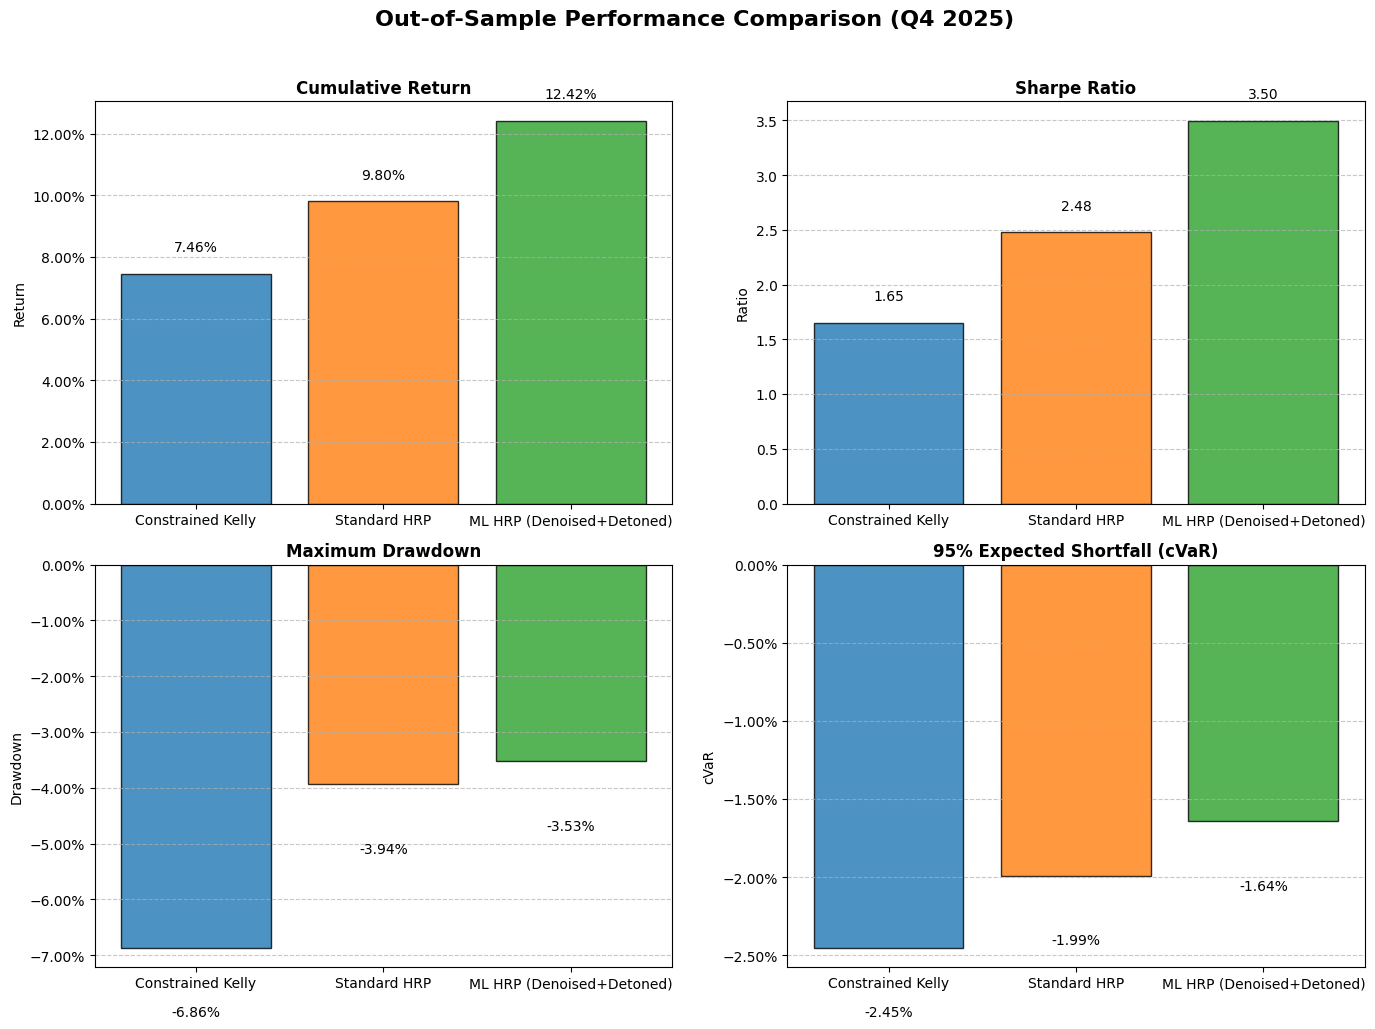

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Extract raw numeric data from our df_step6_oos variables for plotting
strategies = df_step6_oos.columns.tolist()

returns_vals = [calc_cumulative_return(df_step6_oos[col]) * 100 for col in strategies]
sharpe_vals = [calc_sharpe_ratio(df_step6_oos[col]) for col in strategies]
drawdown_vals = [calc_max_drawdown(df_step6_oos[col]) * 100 for col in strategies]
cvar_vals = [calc_cvar(df_step6_oos[col]) * 100 for col in strategies]

# Function to help sort and plot
def plot_sorted_bar(ax, strategies, values, title, ylabel, is_percentage=False):
    # Sort the data
    sorted_pairs = sorted(zip(strategies, values), key=lambda x: x[1])
    sorted_strats = [x[0] for x in sorted_pairs]
    sorted_vals = [x[1] for x in sorted_pairs]

    # Create colors based on strategy name to maintain consistency
    color_map = {'Constrained Kelly': '#1f77b4', 'Standard HRP': '#ff7f0e', 'ML HRP (Denoised+Detoned)': '#2ca02c'}
    colors = [color_map[s] for s in sorted_strats]

    bars = ax.bar(sorted_strats, sorted_vals, color=colors, edgecolor='black', alpha=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    if is_percentage:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))

    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        label_y_pos = height + (0.05 * max(sorted_vals)) if height > 0 else height - (0.15 * abs(min(sorted_vals)))
        fmt_str = f'{height:.2f}%' if is_percentage else f'{height:.2f}'
        ax.text(bar.get_x() + bar.get_width()/2., label_y_pos, fmt_str, ha='center', va='bottom' if height > 0 else 'top',
                fontsize=10)

# Create a 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.suptitle('Out-of-Sample Performance Comparison (Q4 2025)', fontsize=16, fontweight='bold', y=1.02)

# Plot each metric
plot_sorted_bar(axes[0, 0], strategies, returns_vals, 'Cumulative Return', 'Return', is_percentage=True)
plot_sorted_bar(axes[0, 1], strategies, sharpe_vals, 'Sharpe Ratio', 'Ratio', is_percentage=False)
plot_sorted_bar(axes[1, 0], strategies, drawdown_vals, 'Maximum Drawdown', 'Drawdown', is_percentage=True)
plot_sorted_bar(axes[1, 1], strategies, cvar_vals, '95% Expected Shortfall (cVaR)', 'cVaR', is_percentage=True)

plt.tight_layout()
plt.savefig('oos_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()